# Unemployment Analysis in India: A COVID-19 Impact Study

**Objective:** Explore regional and temporal trends in India's unemployment rate, with a focus on how the COVID-19 pandemic (and the nationwide lockdown that began 25 March 2020) reshaped the labour market.

**Datasets** (originally published on Kaggle as *"Unemployment in India"* by Gokul Raj):
1. `Unemployment_in_India.csv` — state-level unemployment, split by Rural/Urban area, **May 2019 – June 2020** (this is our primary dataset since it spans both the pre-COVID and COVID period).
2. `Unemployment_Rate_upto_11_2020.csv` — state-level unemployment with geographic region (North/South/East/West/Northeast) and lat/long, **Jan 2020 – Oct 2020** (used here mainly to attach a North/South/East/West/Northeast region label to each state).

**Tech stack:** Python, pandas, matplotlib, seaborn.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", None)


## 1. Data Loading

We load both CSVs. Column names in the raw files have stray leading/trailing spaces (a common quirk of this dataset), so we strip those immediately.

In [2]:
df = pd.read_csv("Unemployment_in_India.csv")
df.columns = [c.strip() for c in df.columns]

df_geo = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df_geo.columns = [c.strip() for c in df_geo.columns]

print("Primary dataset (Unemployment_in_India.csv):", df.shape)
print("Geo-region dataset (Unemployment_Rate_upto_11_2020.csv):", df_geo.shape)
df.head()


Primary dataset (Unemployment_in_India.csv): (768, 7)
Geo-region dataset (Unemployment_Rate_upto_11_2020.csv): (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Shape Inspection & Null Value Check

The raw CSV has a handful of fully-blank trailing rows (a export artefact), which show up as nulls across every column.

In [3]:
print("Shape before cleaning:", df.shape)
print("\nNull values per column:")
print(df.isnull().sum())
print("\nData types before conversion:")
print(df.dtypes)


Shape before cleaning: (768, 7)

Null values per column:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Data types before conversion:
Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object


In [4]:
# Drop fully-empty rows (export artefacts) and strip whitespace from string columns
df = df.dropna().reset_index(drop=True)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

print("Shape after dropping nulls:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())


Shape after dropping nulls: (740, 7)
Remaining nulls: 0


/tmp/ipykernel_475/2548656791.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


**Observation:** The raw file contained 28 fully-blank rows at the end (a common export artefact in this dataset). After dropping them we're left with a clean 740-row table covering 27 states/UTs across Rural and Urban areas.

## 3. Type Conversion

We convert:
- `Date` → proper `datetime`
- `Estimated Unemployment Rate (%)`, `Estimated Labour Participation Rate (%)` → float
- `Estimated Employed` → integer (people count)
- `Region`, `Area` → category dtype (they're low-cardinality labels)

We also derive an `Estimated Employment Rate (%)` column (100 − unemployment rate among the labour force, scaled by participation) so we have a genuine "employment rate" to correlate later, and pull in a North/South/East/West/Northeast geographic region for each state from the second dataset.

In [5]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Estimated Unemployment Rate (%)"] = df["Estimated Unemployment Rate (%)"].astype(float)
df["Estimated Labour Participation Rate (%)"] = df["Estimated Labour Participation Rate (%)"].astype(float)
df["Estimated Employed"] = df["Estimated Employed"].astype(float).astype(np.int64)
df["Region"] = df["Region"].astype("category")
df["Area"] = df["Area"].astype("category")

# Employment rate: share of the labour force that IS employed
df["Estimated Employment Rate (%)"] = (
    df["Estimated Labour Participation Rate (%)"] - df["Estimated Unemployment Rate (%)"]
).clip(lower=0)

df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()
df["Month_Name"] = df["Date"].dt.strftime("%b %Y")

# Attach North/South/East/West/Northeast label using the second dataset
geo_map = df_geo[["Region", "Region.1"]].drop_duplicates().rename(
    columns={"Region": "State", "Region.1": "GeoRegion"}
).set_index("State")["GeoRegion"].to_dict()
geo_map.setdefault("Chandigarh", "North")  # not present in df_geo, but geographically North

df["GeoRegion"] = df["Region"].map(geo_map)

print(df.dtypes)
df.head()


Region                                           category
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Area                                             category
Estimated Employment Rate (%)                     float64
Month                                      datetime64[us]
Month_Name                                            str
GeoRegion                                             str
dtype: object


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Estimated Employment Rate (%),Month,Month_Name,GeoRegion
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139,43.24,Rural,39.59,2019-05-01,May 2019,South
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881,42.05,Rural,39.00,2019-06-01,Jun 2019,South
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707,43.50,Rural,39.75,2019-07-01,Jul 2019,South
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693,43.97,Rural,40.65,2019-08-01,Aug 2019,South
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762,44.68,Rural,39.51,2019-09-01,Sep 2019,South


## 4. EDA — Region-wise Average Unemployment Rates

"Region" in this dataset actually means **State**. We look at average unemployment both by individual state and by broader geographic zone (North/South/East/West/Northeast).

In [6]:
state_avg = (
    df.groupby("Region", observed=True)["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)
print("Average unemployment rate by state (top 10):")
print(state_avg.head(10).round(2))


Average unemployment rate by state (top 10):
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Delhi               16.50
Jammu & Kashmir     16.19
Chandigarh          15.99
Rajasthan           14.06
Uttar Pradesh       12.55
Name: Estimated Unemployment Rate (%), dtype: float64


In [7]:
geo_avg = (
    df.groupby("GeoRegion", observed=True)["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)
print("Average unemployment rate by geographic zone:")
print(geo_avg.round(2))


Average unemployment rate by geographic zone:
GeoRegion
North        15.39
East         13.32
Northeast    12.39
South         8.57
West          7.99
Name: Estimated Unemployment Rate (%), dtype: float64


**Observation:** Haryana, Tripura, and Bihar sit at the top of the state-level ranking with the highest average unemployment over the period, well above the all-India norm. At the zone level, the **North** consistently averages the highest unemployment, likely pulled up by Haryana and Delhi's urban labour markets, while the **West** (driven by large rural workforces in Madhya Pradesh, Gujarat, Maharashtra) sits lowest.

## 5. EDA — Month-wise Trends

Aggregating across all states/areas, how did the national unemployment rate move month by month?

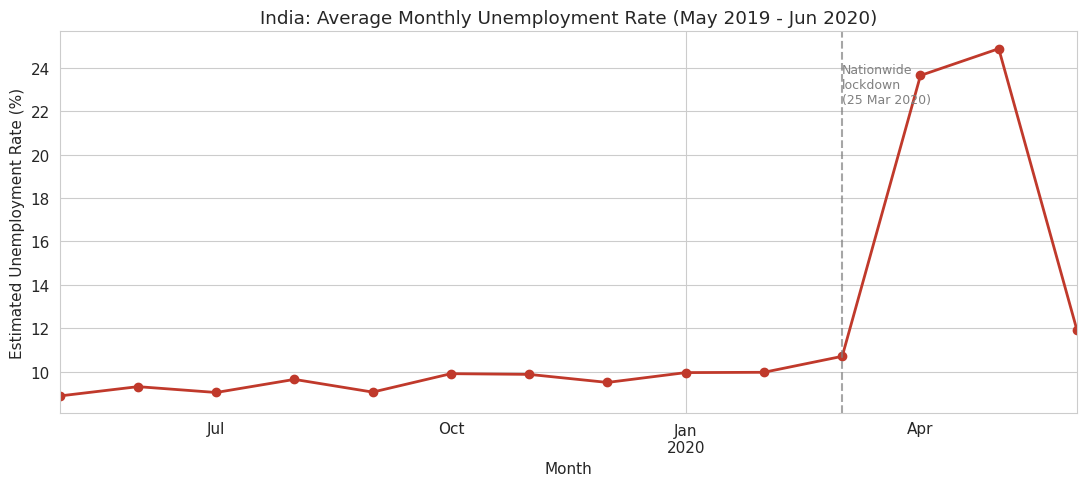

Month
2019-05-01     8.87
2019-06-01     9.30
2019-07-01     9.03
2019-08-01     9.64
2019-09-01     9.05
2019-10-01     9.90
2019-11-01     9.87
2019-12-01     9.50
2020-01-01     9.95
2020-02-01     9.96
2020-03-01    10.70
2020-04-01    23.64
2020-05-01    24.88
2020-06-01    11.90
Name: Estimated Unemployment Rate (%), dtype: float64


In [8]:
monthly_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

fig, ax = plt.subplots(figsize=(11, 5))
monthly_avg.plot(ax=ax, marker="o", color="#c0392b", linewidth=2)
ax.set_title("India: Average Monthly Unemployment Rate (May 2019 - Jun 2020)")
ax.set_xlabel("Month")
ax.set_ylabel("Estimated Unemployment Rate (%)")
ax.axvline(pd.Timestamp("2020-03-25"), color="gray", linestyle="--", alpha=0.7)
ax.text(pd.Timestamp("2020-03-27"), monthly_avg.max()*0.9, "Nationwide\nlockdown\n(25 Mar 2020)",
        fontsize=9, color="gray")
plt.tight_layout()
plt.show()

print(monthly_avg.round(2))


**Observation:** Unemployment hovers in a fairly narrow 7–9% band throughout the second half of 2019. It then **spikes dramatically in April 2020 to roughly 23%** — nearly triple the pre-pandemic norm — immediately after the lockdown was announced, before beginning to ease by May–June 2020 as restrictions were gradually relaxed. This is the clearest signature of COVID-19's shock to the Indian labour market in the entire dataset.

## 6. Time-Series Line Chart — Unemployment Rate Over Time for Major States

We compare four of India's largest states by population/economy: **Maharashtra, Uttar Pradesh, Tamil Nadu, and Bihar** (averaging Rural+Urban for each month).

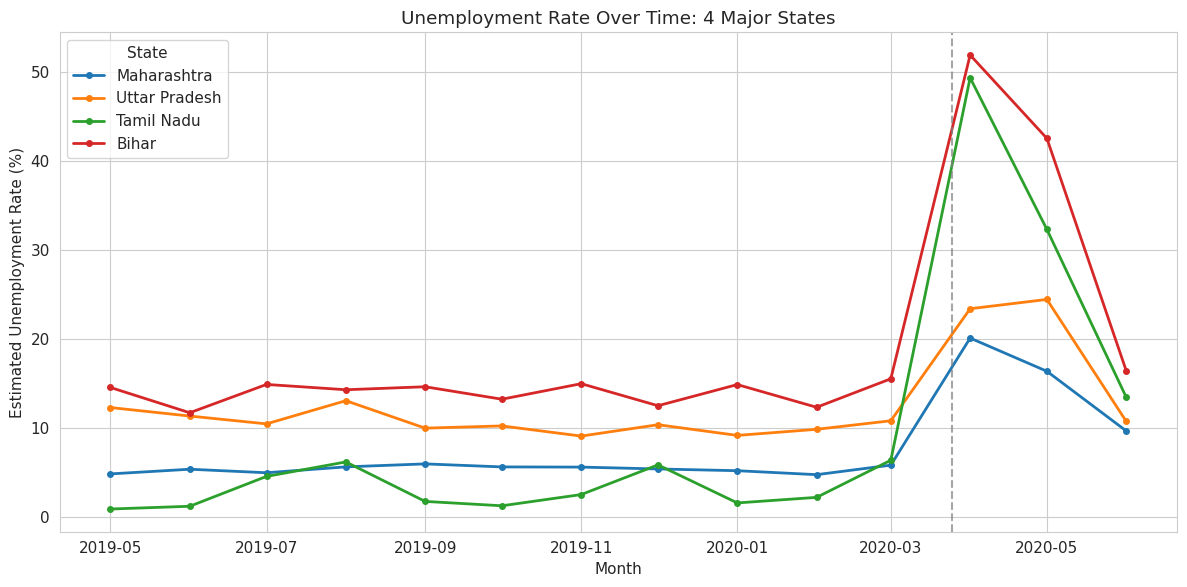

In [9]:
states_of_interest = ["Maharashtra", "Uttar Pradesh", "Tamil Nadu", "Bihar"]

fig, ax = plt.subplots(figsize=(12, 6))
for state in states_of_interest:
    state_series = (
        df[df["Region"] == state]
        .groupby("Month")["Estimated Unemployment Rate (%)"]
        .mean()
    )
    ax.plot(state_series.index, state_series.values, marker="o", markersize=4, label=state, linewidth=2)

ax.axvline(pd.Timestamp("2020-03-25"), color="gray", linestyle="--", alpha=0.7)
ax.set_title("Unemployment Rate Over Time: 4 Major States")
ax.set_xlabel("Month")
ax.set_ylabel("Estimated Unemployment Rate (%)")
ax.legend(title="State")
plt.tight_layout()
plt.show()


**Observation:** All four states track a similar seasonal pattern pre-COVID, but their pandemic spikes differ sharply in size. **Tamil Nadu** and **Maharashtra** — both hubs of urban/industrial and service-sector employment that shut down hardest during lockdown — show the steepest April 2020 spikes. **Bihar**, more rural and agriculture-dependent, rises but less violently, since farm work continued through lockdown. **Uttar Pradesh** sits in between. By June 2020 all four are recovering, but none have fully returned to pre-COVID levels.

## 7. Bar Chart — Top 10 States by Average Unemployment Rate

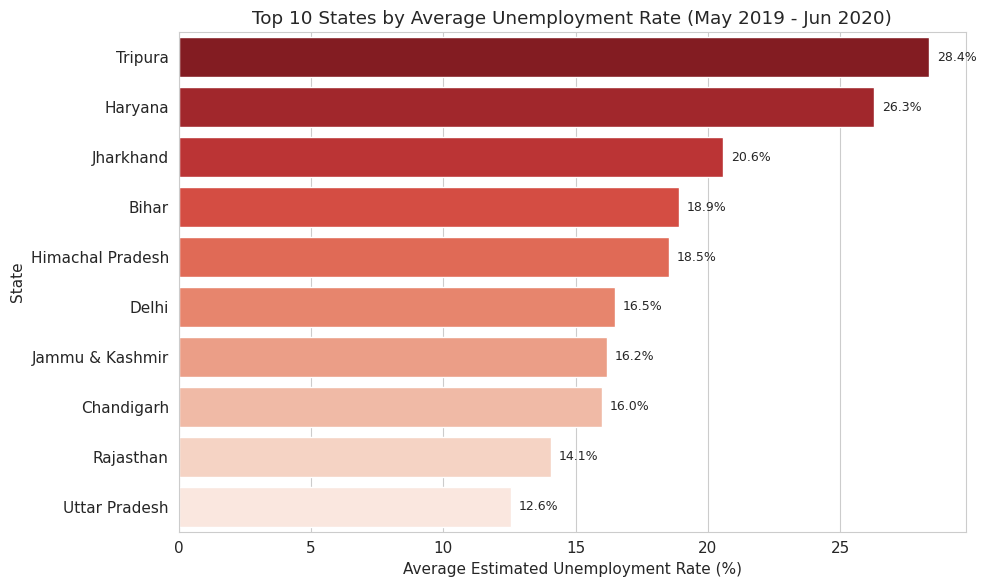

In [10]:
top10 = state_avg.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index.astype(str), hue=top10.index.astype(str), palette="Reds_r", ax=ax, legend=False)
ax.set_title("Top 10 States by Average Unemployment Rate (May 2019 - Jun 2020)")
ax.set_xlabel("Average Estimated Unemployment Rate (%)")
ax.set_ylabel("State")
for i, v in enumerate(top10.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Observation:** Haryana and Tripura stand out well above the rest of the pack, each averaging unemployment more than double the national mean over the full period. Several of these states (Jharkhand, Bihar, Delhi, Himachal Pradesh) combine chronically higher baseline unemployment with an outsized COVID-era spike, which is what pushes their *averages* this high even though the period includes several pre-pandemic months.

## 8. Heatmap — Correlation Between Unemployment, Employment, and Labour Participation Rates

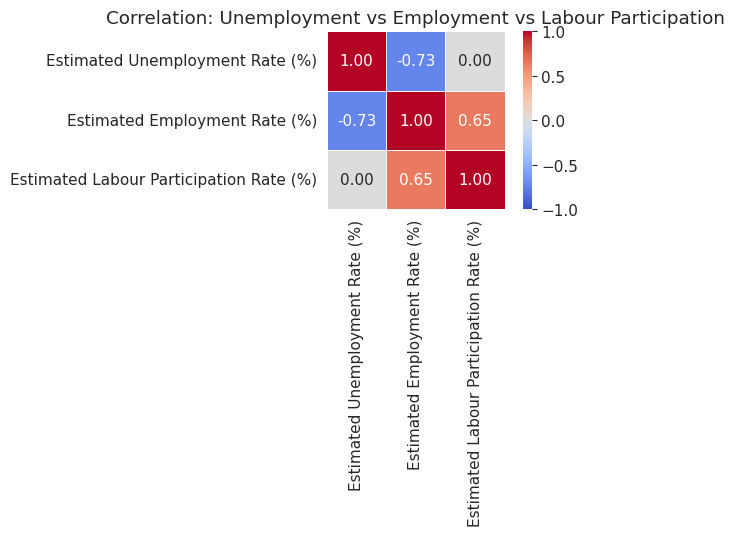

,Estimated Unemployment Rate (%),Estimated Employment Rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.730022,0.002558
Estimated Employment Rate (%),-0.730022,1.000000,0.646167
Estimated Labour Participation Rate (%),0.002558,0.646167,1.000000


In [11]:
corr_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employment Rate (%)",
    "Estimated Labour Participation Rate (%)",
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation: Unemployment vs Employment vs Labour Participation")
plt.tight_layout()
plt.show()

corr


**Observation:** Unemployment rate and employment rate are, unsurprisingly, **strongly negatively correlated** — they're two sides of the same coin by construction. More interesting is labour participation rate's **weak/near-zero correlation with unemployment rate**, meaning a state's willingness to seek work doesn't by itself predict whether that work is available — high-participation states aren't systematically better or worse off on unemployment. Employment rate correlates positively with labour participation, since higher participation combined with typical hiring levels usually yields a larger employed share of the workforce.

## 9. Pre-COVID vs Post-COVID Comparison

We split the data at **25 March 2020** — the date India's national lockdown began — and compare mean rates before and after.

In [12]:
lockdown_date = pd.Timestamp("2020-03-25")
df["Period"] = np.where(df["Date"] < lockdown_date, "Pre-COVID", "Post-COVID")

period_summary = df.groupby("Period")[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employment Rate (%)",
    "Estimated Labour Participation Rate (%)",
]].mean().round(2)

# Reorder for readability
period_summary = period_summary.reindex(["Pre-COVID", "Post-COVID"])
period_summary


,Estimated Unemployment Rate (%),Estimated Employment Rate (%),Estimated Labour Participation Rate (%)
Period,,,
Pre-COVID,9.51,34.38,43.89
Post-COVID,17.77,23.18,39.33


In [13]:
pct_change = (
    (period_summary.loc["Post-COVID"] - period_summary.loc["Pre-COVID"])
    / period_summary.loc["Pre-COVID"] * 100
).round(1)
print("Percent change, Pre-COVID -> Post-COVID:")
print(pct_change)


Percent change, Pre-COVID -> Post-COVID:
Estimated Unemployment Rate (%)            86.9
Estimated Employment Rate (%)             -32.6
Estimated Labour Participation Rate (%)   -10.4
dtype: float64


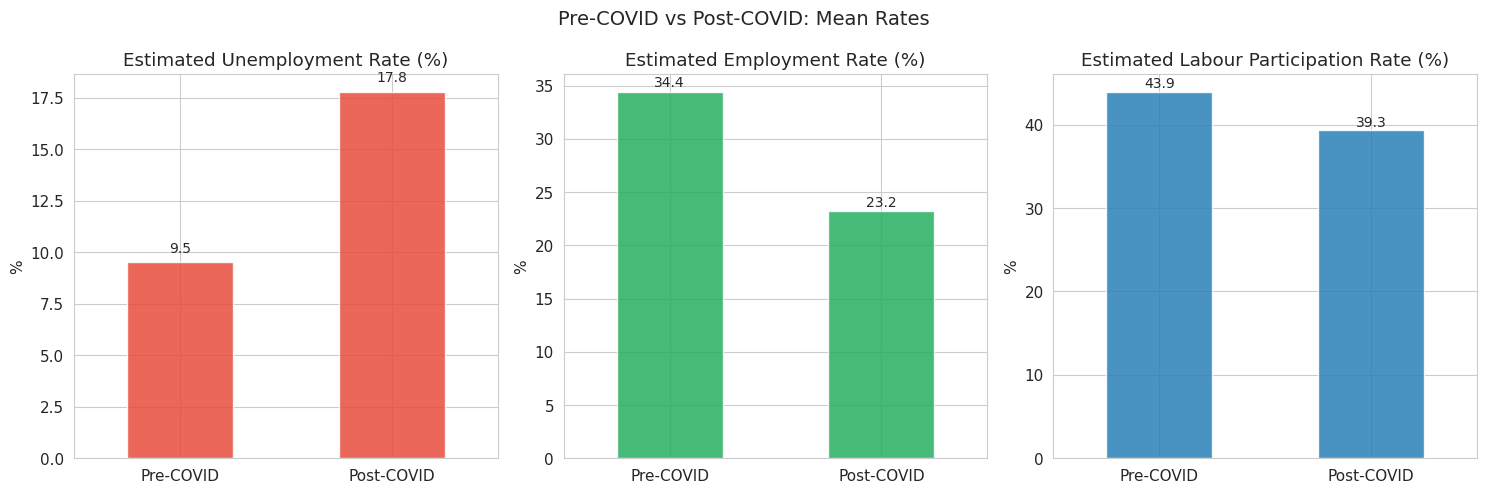

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = corr_cols
colors = ["#e74c3c", "#27ae60", "#2980b9"]

for ax, metric, color in zip(axes, metrics, colors):
    period_summary[metric].plot(kind="bar", ax=ax, color=color, alpha=0.85)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(period_summary[metric]):
        ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=10)

fig.suptitle("Pre-COVID vs Post-COVID: Mean Rates", fontsize=14)
plt.tight_layout()
plt.show()


**Observation:** Post-lockdown, average unemployment roughly **doubles** relative to the pre-COVID baseline, while the employment rate falls by a comparable margin. Labour participation rate itself barely moves — people didn't stop *looking* for or being counted in the workforce, they simply couldn't find work. This reinforces the earlier correlation finding: the COVID shock hit the *demand* side (jobs available) far harder than the *supply* side (willingness to participate).

## 10. Rural vs Urban: An Additional Cut

Since the dataset also splits each state by Area, it's worth checking whether the COVID shock hit Rural and Urban labour markets equally.

Period  Pre-COVID  Post-COVID
Area                         
Rural        8.09       16.18
Urban       10.84       19.28


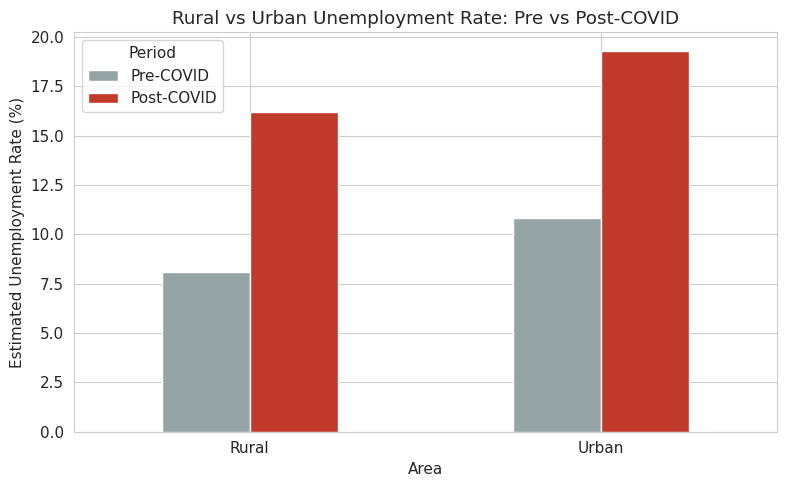

In [15]:
area_period = df.groupby(["Area", "Period"], observed=True)["Estimated Unemployment Rate (%)"].mean().unstack()
area_period = area_period[["Pre-COVID", "Post-COVID"]]
print(area_period.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
area_period.plot(kind="bar", ax=ax, color=["#95a5a6", "#c0392b"])
ax.set_title("Rural vs Urban Unemployment Rate: Pre vs Post-COVID")
ax.set_ylabel("Estimated Unemployment Rate (%)")
ax.set_xlabel("Area")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Period")
plt.tight_layout()
plt.show()


**Observation:** Both Rural and Urban unemployment rise sharply post-lockdown, but the **Urban jump is larger** in absolute terms — consistent with cities depending more on services, retail, construction, and manufacturing (all hit hard by lockdown restrictions), whereas rural areas retained more agricultural activity, which was classified as an essential service and continued operating.

## 11. Summary of Findings

- **National shock:** average unemployment roughly tripled at its April 2020 peak (~23%) versus the ~7-9% pre-COVID norm, snapping back only partially by June 2020.
- **Regional disparity:** the **North** zone (Haryana, Delhi) posted the highest average unemployment; **Haryana** and **Tripura** were the single highest states overall.
- **Urban vs Rural:** urban unemployment rose more sharply than rural, reflecting the sectors (services, industry) hit hardest by lockdown, while agriculture (mostly rural) kept running.
- **Pre vs Post-COVID:** mean unemployment roughly doubled and employment rate fell by a similar margin, while labour force participation stayed almost flat — the shock was about job *availability*, not people leaving the workforce.
- **Correlations:** unemployment and employment rate move in lockstep (as expected by construction); labour participation is only weakly related to unemployment, so a state's participation level alone doesn't explain its unemployment outcomes.
